### CHEM4160 Chemometrics Final Project
#### Topic: Machine Learning Techniques for Accurate Classification of Protein Types
#### Student Name: Tam Wing Ching
#### Student ID: 21007532

### Proposal Link: 
https://drive.google.com/file/d/1P6GtVnZuXyFImpnBSFHBZhPmd3VHJf8F/view?usp=sharing

## Dataset
Shahir. (2015). Structural protein sequences [Data set].
Kaggle. https://www.kaggle.com/datasets/shahir/protein-data-set

## Phase1 Data Preprocessing

### Preparation of the Combined Dataset

#### Import necessary libraries

In [1]:
# Data Manipulation and Analysis
import pandas as pd  # For data manipulation and analysis using DataFrames
import numpy as np   # For numerical operations and array manipulations

# Data Visualization
import seaborn as sns  # For statistical data visualization
import matplotlib.pyplot as plt  # For creating static and interactive plots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score  # For splitting datasets and cross-validation
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For encoding categorical variables and feature scaling
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # For ensemble methods in classification
from sklearn.metrics import classification_report, f1_score  # For evaluating model performance

# Advanced Machine Learning
from xgboost import XGBClassifier  # For using the XGBoost classifier
import lightgbm as lgb  # For using the LightGBM classifier

# Hyperparameter Optimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials  # For optimizing hyperparameters with Hyperopt
from hyperopt.early_stop import no_progress_loss  # For early stopping during optimization
from sklearn.model_selection import GroupKFold  # For group-based cross-validation

# Imputation
from sklearn.impute import KNNImputer  # For filling missing values using KNN

# Model Saving and Loading
import joblib  # For saving and loading models

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


##### Load datasets from CSV files

In [2]:
data1 = pd.read_csv('/kaggle/input/protein-data-set/pdb_data_no_dups.csv')
data2 = pd.read_csv('/kaggle/input/protein-data-set/pdb_data_seq.csv')

##### Display the first 5 rows of the protein dataset

In [3]:
data1.head()

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear
0,100D,DNA-RNA HYBRID,X-RAY DIFFRACTION,DNA/RNA Hybrid,20,1.90,6360.30,"VAPOR DIFFUSION, HANGING DROP",NaN,1.78,30.89,"pH 7.00, VAPOR DIFFUSION, HANGING DROP",7.0,1994.0
1,101D,DNA,X-RAY DIFFRACTION,DNA,24,2.25,7939.35,NaN,NaN,2.00,38.45,NaN,NaN,1995.0
2,101M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.0,1999.0
3,102D,DNA,X-RAY DIFFRACTION,DNA,24,2.20,7637.17,"VAPOR DIFFUSION, SITTING DROP",277.0,2.28,46.06,"pH 7.00, VAPOR DIFFUSION, SITTING DROP, temper...",7.0,1995.0
4,102L,HYDROLASE(O-GLYCOSYL),X-RAY DIFFRACTION,Protein,165,1.74,18926.61,NaN,NaN,2.75,55.28,NaN,NaN,1993.0


##### Display the first 5 rows of the sequence dataset

In [4]:
data2.head()

,structureId,chainId,sequence,residueCount,macromoleculeType
0,100D,A,CCGGCGCCGG,20,DNA/RNA Hybrid
1,100D,B,CCGGCGCCGG,20,DNA/RNA Hybrid
2,101D,A,CGCGAATTCGCG,24,DNA
3,101D,B,CGCGAATTCGCG,24,DNA
4,101M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,154,Protein


##### Calculates and displays the counts and percentages of the top 10 most common classifications in the protein dataset, providing insights into the distribution of classifications.

In [5]:
# Step 1: Get the counts of the top 10 classifications
classification_counts = data1['classification'].value_counts().nlargest(10)

# Step 2: Calculate the total count of classifications
total_count = len(data1)

# Step 3: Calculate the percentage of each classification
classification_percentage = (classification_counts / total_count) * 100

# Step 4: Display the results
print("The 10 most common classification counts and their percentages:")
for classification, count in classification_counts.items():
    percentage = classification_percentage[classification]
    print(f"{classification}: Count = {count}, Percentage = {percentage:.2f}%")

The 10 most common classification counts and their percentages:
HYDROLASE: Count = 20915, Percentage = 14.79%
TRANSFERASE: Count = 15777, Percentage = 11.16%
OXIDOREDUCTASE: Count = 12494, Percentage = 8.84%
LYASE: Count = 4329, Percentage = 3.06%
IMMUNE SYSTEM: Count = 4075, Percentage = 2.88%
TRANSCRIPTION: Count = 3691, Percentage = 2.61%
TRANSPORT PROTEIN: Count = 3251, Percentage = 2.30%
SIGNALING PROTEIN: Count = 2904, Percentage = 2.05%
HYDROLASE/HYDROLASE INHIBITOR: Count = 2677, Percentage = 1.89%
ISOMERASE: Count = 2602, Percentage = 1.84%


##### Visualize the counts of the top 10 most common classification types in the protein dataset using a bar chart.

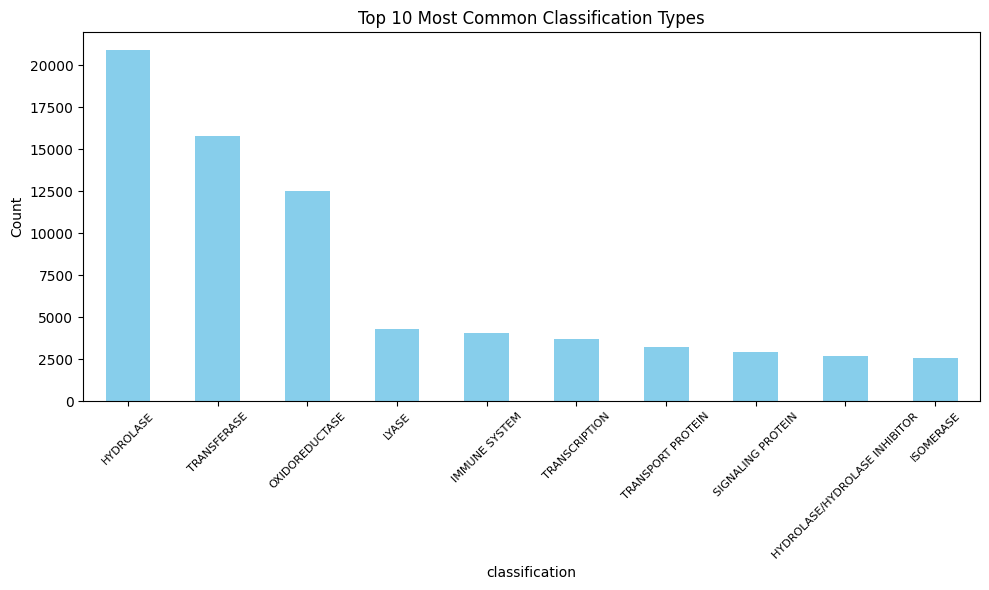

In [6]:
# Get the counts of the top 10 classifications
classification_counts = data1['classification'].value_counts().nlargest(10)

# Plotting the histogram
plt.figure(figsize=(10, 6))
classification_counts.plot(kind='bar', color='skyblue')  # Create a bar plot
plt.title('Top 10 Most Common Classification Types')  # Set the title
plt.ylabel('Count')  # Label for y-axis
plt.xticks(rotation=45, fontsize=8)  # Rotate x-axis labels and set font size
plt.tight_layout()  # Adjust layout to make room for x-labels
plt.show()  # Display the plot

##### For protein dataset, filters the dataset to retain only the entries for the top 10 most common classifications, allowing for focused analysis on the most prevalent categories.

In [7]:
# Get the number of entries before filtering
initial_count = len(data1)
print(f"Number of entries before filtering: {initial_count}")

# Get the counts of each classification
classification_counts = data1['classification'].value_counts()

# Identify the top 10 classifications
top_10_classifications = classification_counts.nlargest(10).index

# Filter the dataset to include only the top 10 classifications
filtered_data = data1[data1['classification'].isin(top_10_classifications)]

# Get the number of entries after filtering
filtered_count = len(filtered_data)
print(f"Number of entries after filtering: {filtered_count}")

# Optionally, update data1 to the filtered dataset
data1 = filtered_data

Number of entries before filtering: 141401
Number of entries after filtering: 72715


##### For sequence dataset, removing duplicate entries based on structureId and sequence ensures data integrity by eliminating redundancy.

In [8]:
# Get the number of entries before filtering
initial_count = len(data2)
print(f"Number of entries before filtering: {initial_count}")

# Remove duplicate rows based on 'structureId' and 'sequence'
data2 = data2.drop_duplicates(subset=['structureId', 'sequence'])

# Get the number of entries after filtering
filtered_count = len(data2)
print(f"Number of entries after filtering: {filtered_count}")

Number of entries before filtering: 467304
Number of entries after filtering: 251720


I plan to join two datasets using the 'structureId' column. However, both datasets include the columns 'residueCount' and 'macromoleculeType'.
To avoid duplication, I will remove these columns from dataset2 before performing the join. 
This is acceptable because the 'residueCount' and 'macromoleculeType' values in the sequence dataset can be safely discarded; they can be retrieved from the protein dataset after the join.
Additionally, different chains for the same protein (with the same structureId) will have identical values for 'residueCount' and 'macromoleculeType', so their removal will not compromise the integrity of the data.

In [9]:
# Drop 'macromoleculeType' and 'residueCount' columns from dataset2
data2.drop(columns=['macromoleculeType', 'residueCount'], inplace=True)

# Join the two datasets together using 'structureId'
data = data1.set_index('structureId').join(data2.set_index('structureId'))

# Get the number of entries in the combined dataset
combined_count = len(data)
print(f"Number of entries in the combined dataset: {combined_count}")

Number of entries in the combined dataset: 94756


In [10]:
# Display the first few rows of the combined dataset
data.head()

,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear,chainId,sequence
structureId,,,,,,,,,,,,,,,
117E,HYDROLASE,X-RAY DIFFRACTION,Protein,572,2.15,65203.21,NaN,NaN,2.71,54.69,"17-19% MPD, 25 MM MES, PH 6.0, 1 MM MNCL2, 0.5...",6.0,1998.0,A,TYTTRQIGAKNTLEYKVYIEKDGKPVSAFHDIPLYADKENNIFNMV...
11BA,HYDROLASE,X-RAY DIFFRACTION,Protein,248,2.06,28700.28,NaN,NaN,2.48,50.36,pH 4.8,4.8,1998.0,A,KESAAAKFERQHMDSGNSPSSSSNYCNLMMCCRKMTQGKCKPVNTF...
11BG,HYDROLASE,X-RAY DIFFRACTION,Protein,248,1.90,30391.41,NaN,NaN,2.40,48.68,pH 4.8,4.8,1999.0,A,KESAAAKFERQHMDSGNSPSSSSNYCNLMMCCRKMTQGKCKPVNTF...
11GS,TRANSFERASE,X-RAY DIFFRACTION,Protein,420,2.30,48366.94,NaN,NaN,2.53,51.44,pH 6.4,6.4,1997.0,A,MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...
14GS,TRANSFERASE,X-RAY DIFFRACTION,Protein,420,2.80,47146.02,NaN,NaN,2.64,53.43,pH 6.6,6.6,1998.0,A,MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...


### Data Exploration and Feature Engineering (Excluding Missing Value Imputation)

#####  Check the number and percentage of missing values for each column

In [11]:
print("Number of missing values per column:")
print(data.isnull().sum())

Number of missing values per column:
classification                  0
experimentalTechnique           0
macromoleculeType            1700
residueCount                    0
resolution                   2951
structureMolecularWeight        0
crystallizationMethod       25893
crystallizationTempK        25110
densityMatthews              7008
densityPercentSol            6993
pdbxDetails                 10196
phValue                     19910
publicationYear             15091
chainId                       114
sequence                      116
dtype: int64


In [12]:
# Calculate the percentage of missing values for each column
missing_percentage = data.isnull().sum() / len(data) * 100

# Format the percentages to two decimal places
formatted_missing_percentage = missing_percentage.apply(lambda x: f"{x:.2f}%")

# Print the formatted percentages
print("Percentage of missing values per column:")
print(formatted_missing_percentage)

Percentage of missing values per column:
classification               0.00%
experimentalTechnique        0.00%
macromoleculeType            1.79%
residueCount                 0.00%
resolution                   3.11%
structureMolecularWeight     0.00%
crystallizationMethod       27.33%
crystallizationTempK        26.50%
densityMatthews              7.40%
densityPercentSol            7.38%
pdbxDetails                 10.76%
phValue                     21.01%
publicationYear             15.93%
chainId                      0.12%
sequence                     0.12%
dtype: object


Our ultimate goal is to predict the "classification" (10 most common protein types) and to utilize the sequence information for this prediction. 
Therefore, we need to drop all rows that lack either classification or sequence information, as these incomplete entries would hinder our ability to make accurate predictions.

In [13]:
data = data.dropna(subset=['classification'])
data = data.dropna(subset=['sequence'])

# Get the number of entries in the combined dataset
combined_count = len(data)
print(f"Number of entries in the combined dataset: {combined_count}")

Number of entries in the combined dataset: 94640


In [14]:
# Displays the data types of all columns
data.dtypes

classification               object
experimentalTechnique        object
macromoleculeType            object
residueCount                  int64
resolution                  float64
structureMolecularWeight    float64
crystallizationMethod        object
crystallizationTempK        float64
densityMatthews             float64
densityPercentSol           float64
pdbxDetails                  object
phValue                     float64
publicationYear             float64
chainId                      object
sequence                     object
dtype: object

##### This code identifies categorical columns in the DataFrame and prints the number of unique categories for each of these columns.

In [15]:
# Identify categorical columns in the DataFrame
categorical_cols = data.select_dtypes(include=['object']).columns

# Print the number of unique categories for each categorical column
for col in categorical_cols:
    num_categories = data[col].nunique()
    print(f"{col}: {num_categories} unique categories")

classification: 10 unique categories
experimentalTechnique: 18 unique categories
macromoleculeType: 7 unique categories
crystallizationMethod: 348 unique categories
pdbxDetails: 51324 unique categories
chainId: 126 unique categories
sequence: 48588 unique categories


##### This code calculates and displays the counts and percentages of the top 20 classifications in the 'pdbxDetails' column.

In [16]:
# Step 1: Get the counts of each classification in 'pdbxDetails'
pdbxDetails_counts = data['pdbxDetails'].value_counts().nlargest(20)

# Step 2: Calculate the total number of entries in the dataset
total_count = len(data)

# Step 3: Calculate the percentage for each of the top classifications
pdbxDetails_percentage = (pdbxDetails_counts / total_count) * 100

# Step 4: Display the results
print("Top 20 pdbxDetails counts and their percentages:")
for pdbxDetails, count in pdbxDetails_counts.items():
    percentage = pdbxDetails_percentage[pdbxDetails]
    print(f"{pdbxDetails}: Count = {count}, Percentage = {percentage:.2f}%")

Top 20 pdbxDetails counts and their percentages:
20 mM MgAC2, 13% MPD, 0.1 M MES: Count = 1576, Percentage = 1.67%
20 MM MGAC2, 13% MPD, PH 6.8, VAPOR DIFFUSION, HANGING DROP, TEMPERATURE 293K: Count = 700, Percentage = 0.74%
15% PEG 3350, 0.05M MgCl2, 0.067M NaCl, 0.1M Tris: Count = 251, Percentage = 0.27%
28% PEG3350 -- 0.1M HEPES pH 7.0 -- 0.25M ammonium sulfate: Count = 248, Percentage = 0.26%
VAPOR DIFFUSION, HANGING DROP: Count = 223, Percentage = 0.24%
pH 7.5: Count = 220, Percentage = 0.23%
pH 7: Count = 215, Percentage = 0.23%
pH 6.5: Count = 194, Percentage = 0.20%
pH 7.0: Count = 167, Percentage = 0.18%
0.1 M Bis-Tris, 0.2 M Magnesium Chloride, 10 % PEG3350: Count = 144, Percentage = 0.15%
0.1M MES pH 6.1 -- 20% PEG20K: Count = 116, Percentage = 0.12%
pH 7.00: Count = 109, Percentage = 0.12%
pH 6.0: Count = 90, Percentage = 0.10%
pH 6.8: Count = 88, Percentage = 0.09%
pH 7.50: Count = 82, Percentage = 0.09%
100 mM MES, 40 mM MgOAc, 15% 2-methyl-2,4-pentanediol (MPD), 10 mM E

##### This code counts the occurrences of each macromolecule type in the dataset, calculates the total number of entries, computes the percentage for each type, and then prints the counts and percentages.

In [17]:
# Step 1: Count occurrences of each macromolecule type
macromolecule_counts = data['macromoleculeType'].value_counts()

# Step 2: Get the total number of entries
total_count = len(data)

# Step 3: Calculate the percentage of each macromolecule type
macromolecule_percentage = (macromolecule_counts / total_count) * 100

# Step 4: Print counts and percentages for each macromolecule type
print("Macromolecule Type counts and their percentages:")
for macromolecule, count in macromolecule_counts.items():
    percentage = macromolecule_percentage[macromolecule]
    print(f"{macromolecule}: Count = {count}, Percentage = {percentage:.2f}%")

Macromolecule Type counts and their percentages:
Protein: Count = 91045, Percentage = 96.20%
Protein#DNA: Count = 1005, Percentage = 1.06%
Protein#DNA#RNA: Count = 691, Percentage = 0.73%
Protein#RNA: Count = 298, Percentage = 0.31%
Protein#DNA/RNA Hybrid: Count = 7, Percentage = 0.01%
RNA: Count = 4, Percentage = 0.00%
Protein#DNA#DNA/RNA Hybrid: Count = 4, Percentage = 0.00%


##### This code counts the occurrences of each macromolecule type in the dataset, calculates the total number of entries, computes the percentage for each type, and then prints the counts and percentages.

In [18]:
# Step 1: Count occurrences of each experimentalTechnique
experimental_technique_counts = data['experimentalTechnique'].value_counts()

# Step 2: Calculate the total count of experimentalTechniques
total_count = len(data)

# Step 3: Calculate and print the percentage of each experimentalTechnique
experimental_technique_percentage = (experimental_technique_counts / total_count) * 100

# Step 4: Display the results
print("Experimental Technique counts and their percentages:")
for technique, count in experimental_technique_counts.items():
    percentage = experimental_technique_percentage[technique]
    print(f"{technique}: Count = {count}, Percentage = {percentage:.2f}%")

Experimental Technique counts and their percentages:
X-RAY DIFFRACTION: Count = 88298, Percentage = 93.30%
ELECTRON MICROSCOPY: Count = 3320, Percentage = 3.51%
SOLUTION NMR: Count = 2809, Percentage = 2.97%
ELECTRON CRYSTALLOGRAPHY: Count = 42, Percentage = 0.04%
SOLUTION SCATTERING: Count = 32, Percentage = 0.03%
NEUTRON DIFFRACTION: Count = 32, Percentage = 0.03%
NEUTRON DIFFRACTION, X-RAY DIFFRACTION: Count = 31, Percentage = 0.03%
X-RAY DIFFRACTION, NEUTRON DIFFRACTION: Count = 26, Percentage = 0.03%
SOLID-STATE NMR: Count = 17, Percentage = 0.02%
POWDER DIFFRACTION: Count = 15, Percentage = 0.02%
SOLUTION SCATTERING, SOLUTION NMR: Count = 5, Percentage = 0.01%
SOLUTION NMR, SOLUTION SCATTERING: Count = 3, Percentage = 0.00%
SOLUTION NMR, THEORETICAL MODEL: Count = 3, Percentage = 0.00%
X-RAY DIFFRACTION, EPR: Count = 3, Percentage = 0.00%
INFRARED SPECTROSCOPY: Count = 1, Percentage = 0.00%
EPR, X-RAY DIFFRACTION: Count = 1, Percentage = 0.00%
SOLUTION SCATTERING, X-RAY DIFFRACTI

##### Crystallization Method and Temperature: Both have around 25% missing values, making them less reliable.
##### Chain ID: This is just an identifier and does not contribute to protein prediction.
##### Publication Year: It appears unhelpful for predicting protein types.
##### PDBx Details: Contains diverse sentences with excessive uniqueness, complicating analysis.
##### Experimental Technique: With 94.97% of entries being X-RAY DIFFRACTION, it lacks diversity. 
##### Macromolecule Type: 96.58% of entries are proteins, indicating low variability.

In [19]:
data = data.drop(columns=['publicationYear','chainId', 'pdbxDetails','experimentalTechnique', 'macromoleculeType', 'crystallizationMethod','crystallizationTempK'])

#####  Check the percentage of missing values for each column again

In [20]:
# Calculate the percentage of missing values for each column
missing_percentage = data.isnull().sum() / len(data) * 100

# Format the percentages to two decimal places
formatted_missing_percentage = missing_percentage.apply(lambda x: f"{x:.2f}%")

# Print the formatted percentages
print("Percentage of missing values per column:")
print(formatted_missing_percentage)

Percentage of missing values per column:
classification               0.00%
residueCount                 0.00%
resolution                   3.10%
structureMolecularWeight     0.00%
densityMatthews              7.39%
densityPercentSol            7.38%
phValue                     21.01%
sequence                     0.00%
dtype: object


The provided code calculates the average hydropathy index of protein sequences using the Kyte-Doolittle scale, which assigns numerical values to amino acids based on their hydrophobic or hydrophilic properties. 
This calculation helps in assessing the overall hydrophobicity of a protein, which is crucial for predicting its behavior and interactions in biological systems. Additionally, the code computes the length of each protein sequence and removes the original sequence data from the DataFrame, resulting in a cleaner dataset for further analysis.

In [21]:
kyte_doolittle_scale = {
    'A': 1.8,   # Alanine
    'C': 2.5,   # Cysteine
    'D': -3.5,  # Aspartic Acid
    'E': -3.5,  # Glutamic Acid
    'F': 2.8,   # Phenylalanine
    'G': -0.4,  # Glycine
    'H': -3.2,  # Histidine
    'I': 4.5,   # Isoleucine
    'K': -3.9,  # Lysine
    'L': 3.8,   # Leucine
    'M': 1.9,   # Methionine
    'N': -3.5,  # Asparagine
    'P': -1.6,  # Proline
    'Q': -3.5,  # Glutamine
    'R': -4.5,  # Arginine
    'S': -0.8,  # Serine
    'T': -0.7,  # Threonine
    'V': 4.2,   # Valine
    'W': -0.9,  # Tryptophan
    'Y': -1.3   # Tyrosine
}

# Function to calculate the average hydropathy index of a sequence
def calculate_hydropathy_index(sequence):
    total_hydropathy = sum(kyte_doolittle_scale.get(aa, 0) for aa in sequence)
    avg_hydropathy = total_hydropathy / len(sequence) if len(sequence) > 0 else 0
    return avg_hydropathy

# Apply the function to the sequence column
data['average_hydropathy_index'] = data['sequence'].apply(calculate_hydropathy_index)

# Calculate the length of each sequence as a new column
data['sequence_length'] = data['sequence'].apply(len)

# Drop the 'sequence' column from the DataFrame
data = data.drop(columns=['sequence'])

# Display the first few rows of the updated DataFrame
data.head()

,classification,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,,,
117E,HYDROLASE,572,2.15,65203.21,2.71,54.69,6.0,-0.507343,286
11BA,HYDROLASE,248,2.06,28700.28,2.48,50.36,4.8,-0.612097,124
11BG,HYDROLASE,248,1.90,30391.41,2.40,48.68,4.8,-0.612097,124
11GS,TRANSFERASE,420,2.30,48366.94,2.53,51.44,6.4,-0.121429,210
14GS,TRANSFERASE,420,2.80,47146.02,2.64,53.43,6.6,-0.121429,210


In [22]:
combined_count = len(data)
print(f"Number of entries in the combined dataset: {combined_count}")

Number of entries in the combined dataset: 94640


Preventing data leakage is crucial; by fitting the encoder only on the training data, we can avoid introducing bias from the test data into your model. 
This ensures consistency, as using the same encoder guarantees that labels are encoded uniformly across both datasets. 
##### However, to check the correlation matrix, I duplicated the data and applied label encoding to the entire dataset.

In [23]:
# Duplicate the DataFrame
data_duplicate = data.copy()

In [24]:
cats = ['classification']
label_encoders = {}

for cat in cats:
    label_encoder = LabelEncoder()
    # Fit the encoder on the training data and transform both training and testing sets
    data_duplicate[cat] = label_encoder.fit_transform(data_duplicate[cat])  # Replace original with encoded
    label_encoders[cat] = label_encoder  # Store the encoder for potential inverse transformation


##### Visualize the correlation matrix

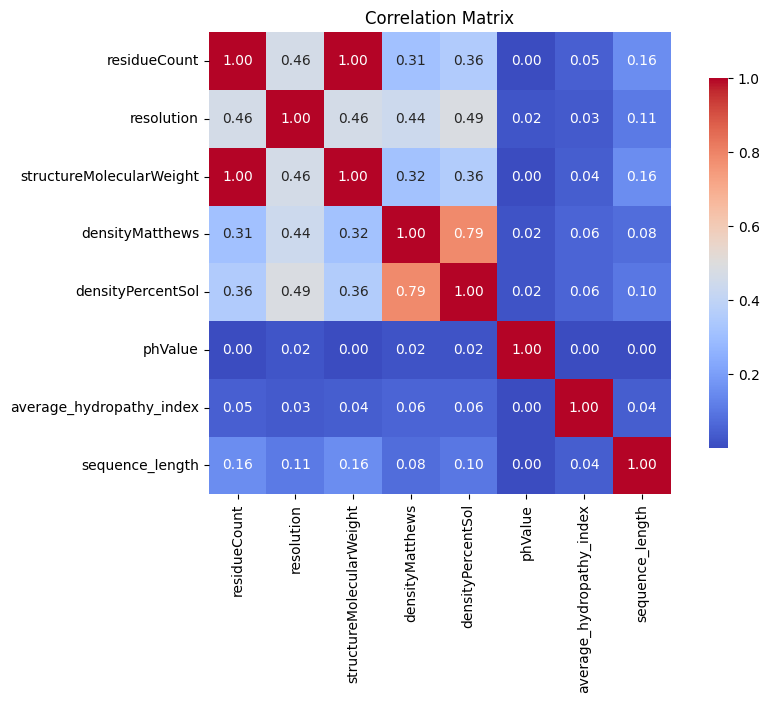

In [25]:
numerical_data = data_duplicate.drop(columns=['classification'])
correlation_matrix = numerical_data.corr()
# Step 3: Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

##### Dropping residueCount and densityPercentSol is advisable due to their strong correlations with specific feature. 
Specifically, residueCount and structureMolecularWeight exhibit a very strong positive correlation (approximately 1.00), while densityPercentSol and densityMatthews show a strong positive correlation (around 0.79). By removing these features, we can reduce complexity in the model and enhance interpretability.

In [26]:
data_duplicate.drop(columns=['residueCount', 'densityPercentSol'], inplace=True)

##### Visualize the correlation matrix again

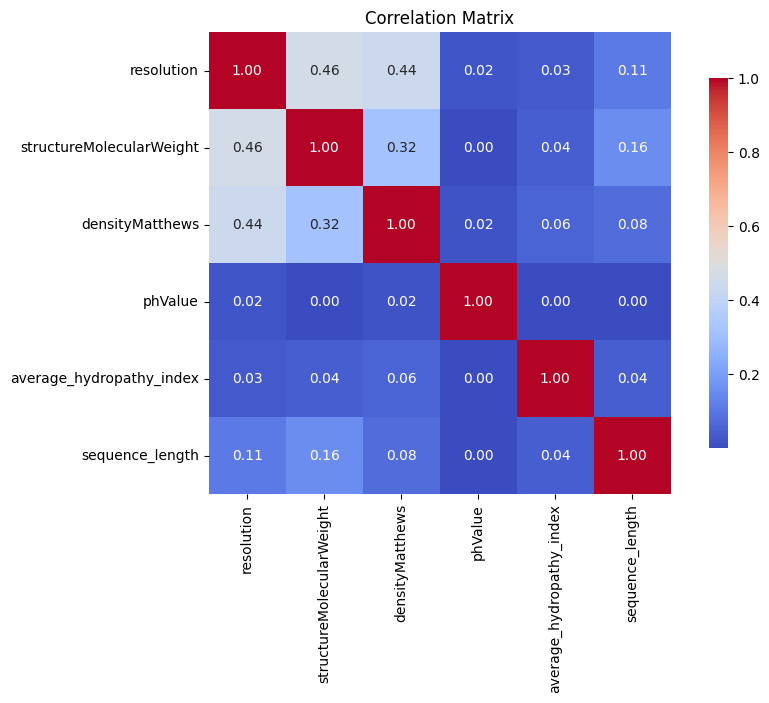

In [27]:
numerical_data = data_duplicate.drop(columns=['classification'])
correlation_matrix = numerical_data.corr()

# Step 3: Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

##### The effect is quite good, also drop them in data.

In [28]:
data.drop(columns=['residueCount', 'densityPercentSol'], inplace=True)

##### Save the cleaned dataset to a CSV file and then read it back into a DataFrame. This approach allows us to avoid re-running the previous code to obtain the tidied data.

In [29]:
# Save the cleaned dataset to a CSV file
data.to_csv('data.csv', index=True)

In [30]:
# Read the tidied data from the CSV file and set 'structureId' as the index
data = pd.read_csv('data.csv', index_col='structureId')

# Display the first few rows of the DataFrame
data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
117E,HYDROLASE,2.15,65203.21,2.71,6.0,-0.507343,286
11BA,HYDROLASE,2.06,28700.28,2.48,4.8,-0.612097,124
11BG,HYDROLASE,1.90,30391.41,2.40,4.8,-0.612097,124
11GS,TRANSFERASE,2.30,48366.94,2.53,6.4,-0.121429,210
14GS,TRANSFERASE,2.80,47146.02,2.64,6.6,-0.121429,210


In [31]:
print(data.head())

            classification  resolution  structureMolecularWeight  \
structureId                                                        
117E             HYDROLASE        2.15                  65203.21   
11BA             HYDROLASE        2.06                  28700.28   
11BG             HYDROLASE        1.90                  30391.41   
11GS           TRANSFERASE        2.30                  48366.94   
14GS           TRANSFERASE        2.80                  47146.02   

             densityMatthews  phValue  average_hydropathy_index  \
structureId                                                       
117E                    2.71      6.0                 -0.507343   
11BA                    2.48      4.8                 -0.612097   
11BG                    2.40      4.8                 -0.612097   
11GS                    2.53      6.4                 -0.121429   
14GS                    2.64      6.6                 -0.121429   

             sequence_length  
structureId           

### Train-Test Split (Preventing Data Leakage), Imputation of Missing Values (KNN Imputer), Label Encoding, and Standardization

##### Now, I need to prevent data leakage by ensuring that proteins with the same structure ID are not present in both the training and test sets.
This is crucial because including the same structure ID in both sets can lead to biased performance evaluation. If the model has seen data from the same protein during training, it may perform artificially well on the test set, as it can exploit similarities rather than generalizing to new, unseen data. 
By keeping the training and test sets distinct in terms of structure IDs, we ensure a more accurate assessment of the model's ability to generalize to new examples, thereby improving the reliability of our predictions.

#### Noted:
Using larger sequence lengths for the test set is a great suggestion, as it allows us to predict larger sequences (which contain more information) using proteins with shorter sequences (which contain less information). However, a potential issue is that the cross-validation (CV) score calculated from the training set may not accurately reflect the model's performance, since it primarily evaluates its ability to predict shorter sequences.

This could lead to a model that performs poorly due to a lack of diversity in the training set. To address this, incorporating a balanced representation of all sequence lengths in both the training and test sets will enable us to evaluate the model's performance across various protein types more effectively.

In [32]:
# Get unique structure IDs and their corresponding classifications from the index
unique_structure_ids = data.index.unique()

# Create a DataFrame for unique structure IDs and their classifications
structure_id_classifications = data[['classification']].reset_index().drop_duplicates()

# Split unique structure IDs while stratifying by classification
train_ids, test_ids = train_test_split(
    structure_id_classifications['structureId'],
    test_size=0.3,
    random_state=42,
    stratify=structure_id_classifications['classification']  # Stratify by the target variable
)

# Step 3: Create training and test sets based on the structure IDs
train_data = data[data.index.isin(train_ids)]
test_data = data[data.index.isin(test_ids)]

In [33]:
train_data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
117E,HYDROLASE,2.15,65203.21,2.71,6.0,-0.507343,286
11BG,HYDROLASE,1.90,30391.41,2.40,4.8,-0.612097,124
11GS,TRANSFERASE,2.30,48366.94,2.53,6.4,-0.121429,210
14GS,TRANSFERASE,2.80,47146.02,2.64,6.6,-0.121429,210
177L,HYDROLASE,2.50,18562.37,2.92,8.6,-0.359146,164


In [34]:
test_data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
11BA,HYDROLASE,2.06,28700.28,2.48,4.8,-0.612097,124
16GS,TRANSFERASE,1.90,47242.08,2.53,5.8,-0.121429,210
19GS,TRANSFERASE,1.90,49082.30,2.57,6.0,-0.131100,209
1A05,OXIDOREDUCTASE,2.00,77411.23,2.83,6.5,-0.001955,358
1A0F,TRANSFERASE,2.10,46503.33,2.40,4.6,-0.220398,201


In [35]:
# Display the sizes of the training and test sets
print(f"Training set size: {train_data.shape[0]}")
print(f"Test set size: {test_data.shape[0]}")

Training set size: 66467
Test set size: 28173


##### Consider addressing data leakage by ensuring that proteins with the same structure ID do not appear in both the training and test sets. This may result in slight differences in the classification distribution between the training and test sets

In [36]:
def print_classification_distribution(data, set_name):
    print(f"\n{set_name} set classification distribution:")
    distribution = data['classification'].value_counts(normalize=True) * 100  # Convert to percentage
    for classification, proportion in distribution.items():
        print(f"{classification}: {proportion:.2f}%")

# Print the distributions
print_classification_distribution(train_data, "Training")
print_classification_distribution(test_data, "Testing")


Training set classification distribution:
HYDROLASE: 26.43%
TRANSFERASE: 18.62%
OXIDOREDUCTASE: 15.85%
IMMUNE SYSTEM: 9.73%
HYDROLASE/HYDROLASE INHIBITOR: 7.06%
TRANSCRIPTION: 6.55%
LYASE: 4.91%
TRANSPORT PROTEIN: 4.18%
SIGNALING PROTEIN: 3.83%
ISOMERASE: 2.84%

Testing set classification distribution:
HYDROLASE: 26.63%
TRANSFERASE: 18.89%
OXIDOREDUCTASE: 16.22%
IMMUNE SYSTEM: 9.70%
TRANSCRIPTION: 6.51%
HYDROLASE/HYDROLASE INHIBITOR: 6.19%
LYASE: 4.95%
TRANSPORT PROTEIN: 4.18%
SIGNALING PROTEIN: 3.85%
ISOMERASE: 2.88%


#### Fill the Missing Data

##### [Traing set] Calculate and display the percentage of missing values for each numeric feature with missing values, grouped by each type of protein classification.

In [37]:
# Step 1: Define the columns to check for missing values
cols_to_check = ['resolution', 'densityMatthews', 'phValue']

# Step 2: Group by classification and calculate the missing percentage for each feature
for col in cols_to_check:
    missing_percentage = train_data.groupby('classification')[col].apply(lambda x: x.isnull().mean() * 100)
    print(f"Missing value percentages for '{col}' by protein type:")
    print(missing_percentage)
    print("\n")  # For better readability


Missing value percentages for 'resolution' by protein type:
classification
HYDROLASE                         2.129234
HYDROLASE/HYDROLASE INHIBITOR     0.532822
IMMUNE SYSTEM                     1.870748
ISOMERASE                         4.827586
LYASE                             0.214658
OXIDOREDUCTASE                    1.328778
SIGNALING PROTEIN                15.149137
TRANSCRIPTION                    11.488971
TRANSFERASE                       2.496163
TRANSPORT PROTEIN                 4.926286
Name: resolution, dtype: float64


Missing value percentages for 'densityMatthews' by protein type:
classification
HYDROLASE                         9.518930
HYDROLASE/HYDROLASE INHIBITOR     0.916454
IMMUNE SYSTEM                     3.107607
ISOMERASE                         5.145889
LYASE                             1.471941
OXIDOREDUCTASE                    4.470387
SIGNALING PROTEIN                19.583987
TRANSCRIPTION                    25.275735
TRANSFERASE                       3.

##### [Training set] Calculate and display the count of missing values for each numeric feature that has missing data, grouped by protein classification

In [38]:
# Group by classification and calculate the missing count for each feature
for col in cols_to_check:
    missing_count = train_data.groupby('classification')[col].apply(lambda x: x.isnull().sum())
    print(f"Missing value counts for '{col}' by protein type:")
    print(missing_count)
    print("\n")  # For better readability


Missing value counts for 'resolution' by protein type:
classification
HYDROLASE                        374
HYDROLASE/HYDROLASE INHIBITOR     25
IMMUNE SYSTEM                    121
ISOMERASE                         91
LYASE                              7
OXIDOREDUCTASE                   140
SIGNALING PROTEIN                386
TRANSCRIPTION                    500
TRANSFERASE                      309
TRANSPORT PROTEIN                137
Name: resolution, dtype: int64


Missing value counts for 'densityMatthews' by protein type:
classification
HYDROLASE                        1672
HYDROLASE/HYDROLASE INHIBITOR      43
IMMUNE SYSTEM                     201
ISOMERASE                          97
LYASE                              48
OXIDOREDUCTASE                    471
SIGNALING PROTEIN                 499
TRANSCRIPTION                    1100
TRANSFERASE                       488
TRANSPORT PROTEIN                 406
Name: densityMatthews, dtype: int64


Missing value counts for 'phValue'

Filling missing values with the mean or median is inappropriate due to significant variations in missing rates among protein classifications. For instance, "SIGNALING PROTEIN" has a missing rate of 33.05%, and "TRANSCRIPTION" has 36.97%. Using mean or median values can lead to biased estimates and distort the data.

Instead, a KNN (K-Nearest Neighbors) imputer is preferable. KNN considers the similarities between data points, filling in missing values based on the nearest neighbors, providing a more accurate approach to handling missing data.

#### KNN Imputation for Filling Missing Values in Numeric Features

In [39]:
# Step 1: Define the columns to fill missing values
cols_to_fill = ['resolution', 'densityMatthews', 'phValue']

# Step 2: Create the KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)  # You can adjust n_neighbors

# Step 3: Fit the imputer on train_data and transform both train_data and test_data
train_data.loc[:, cols_to_fill] = knn_imputer.fit_transform(train_data[cols_to_fill])
test_data.loc[:, cols_to_fill] = knn_imputer.transform(test_data[cols_to_fill])


In [40]:
# Calculate the percentage of missing values for each column in train_data
train_missing_percentage = train_data.isnull().sum() / len(train_data) * 100

# Format the percentages to two decimal places
formatted_train_missing_percentage = train_missing_percentage.apply(lambda x: f"{x:.2f}%")

# Print the formatted percentages for train_data
print("Percentage of missing values per column in train_data:")
print(formatted_train_missing_percentage)
print("\n")  # For better readability

# Calculate the percentage of missing values for each column in test_data
test_missing_percentage = test_data.isnull().sum() / len(test_data) * 100

# Format the percentages to two decimal places
formatted_test_missing_percentage = test_missing_percentage.apply(lambda x: f"{x:.2f}%")

# Print the formatted percentages for test_data
print("Percentage of missing values per column in test_data:")
print(formatted_test_missing_percentage)

Percentage of missing values per column in train_data:
classification              0.00%
resolution                  0.00%
structureMolecularWeight    0.00%
densityMatthews             0.00%
phValue                     0.00%
average_hydropathy_index    0.00%
sequence_length             0.00%
dtype: object


Percentage of missing values per column in test_data:
classification              0.00%
resolution                  0.00%
structureMolecularWeight    0.00%
densityMatthews             0.00%
phValue                     0.00%
average_hydropathy_index    0.00%
sequence_length             0.00%
dtype: object


#### Label encoding 

In [41]:
# Define the categorical columns to encode
cats = ['classification']
label_encoders = {}

for cat in cats:
    label_encoder = LabelEncoder()

    # Fit the encoder on the training data and transform both training and testing sets
    train_data.loc[:, cat] = label_encoder.fit_transform(train_data[cat])  # Replace original with encoded
    test_data.loc[:, cat] = label_encoder.transform(test_data[cat])  # Transform test data

    # Store the encoder for potential inverse transformation
    label_encoders[cat] = label_encoder

In [42]:
train_data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
117E,0,2.15,65203.21,2.71,6.0,-0.507343,286
11BG,0,1.90,30391.41,2.40,4.8,-0.612097,124
11GS,8,2.30,48366.94,2.53,6.4,-0.121429,210
14GS,8,2.80,47146.02,2.64,6.6,-0.121429,210
177L,0,2.50,18562.37,2.92,8.6,-0.359146,164


In [43]:
test_data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
11BA,0,2.06,28700.28,2.48,4.8,-0.612097,124
16GS,8,1.90,47242.08,2.53,5.8,-0.121429,210
19GS,8,1.90,49082.30,2.57,6.0,-0.131100,209
1A05,5,2.00,77411.23,2.83,6.5,-0.001955,358
1A0F,8,2.10,46503.33,2.40,4.6,-0.220398,201


#### Standardization

In [44]:
train_data.dtypes

classification               object
resolution                  float64
structureMolecularWeight    float64
densityMatthews             float64
phValue                     float64
average_hydropathy_index    float64
sequence_length               int64
dtype: object

In [45]:
test_data.dtypes

classification               object
resolution                  float64
structureMolecularWeight    float64
densityMatthews             float64
phValue                     float64
average_hydropathy_index    float64
sequence_length               int64
dtype: object

In [46]:
# Define the columns to standardize
columns_to_standardize = [
    'resolution', 'structureMolecularWeight', 
    'densityMatthews', 'phValue', 
    'average_hydropathy_index', 
    'sequence_length'
]

# Ensure Columns are Float using .loc to avoid SettingWithCopyWarning
train_data.loc[:, 'sequence_length'] = train_data['sequence_length'].astype(float)
test_data.loc[:, 'sequence_length'] = test_data['sequence_length'].astype(float)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
train_data.loc[:, columns_to_standardize] = scaler.fit_transform(train_data[columns_to_standardize])
test_data.loc[:, columns_to_standardize] = scaler.transform(test_data[columns_to_standardize])

/tmp/ipykernel_24/3422574118.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.02746228 -0.81572754 -0.39726574 ... -0.40213157 -0.93737342
  0.74133965]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[:, columns_to_standardize] = scaler.fit_transform(train_data[columns_to_standardize])
/tmp/ipykernel_24/3422574118.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.81572754 -0.39726574 -0.40213157 ...  0.45912122 -0.45565576
 -1.39476191]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_data.loc[:, columns_to_standardize] = scaler.transform(test_data[columns_to_standardize])


In [47]:
train_data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
117E,0,-0.154694,-0.343391,-0.119501,-0.165317,-0.596105,-0.027462
11BG,0,-0.322998,-0.478152,-0.432156,-0.407799,-0.886495,-0.815728
11GS,8,-0.053712,-0.408567,-0.301043,-0.084489,0.473694,-0.397266
14GS,8,0.282896,-0.413293,-0.190101,-0.044076,0.473694,-0.397266
177L,0,0.080931,-0.523944,0.092298,0.360061,-0.185287,-0.621094


In [48]:
test_data.head()

,classification,resolution,structureMolecularWeight,densityMatthews,phValue,average_hydropathy_index,sequence_length
structureId,,,,,,,
11BA,0,-0.215284,-0.484699,-0.351471,-0.407799,-0.886495,-0.815728
16GS,8,-0.322998,-0.412921,-0.301043,-0.205731,0.473694,-0.397266
19GS,8,-0.322998,-0.405797,-0.260700,-0.165317,0.446882,-0.402132
1A05,5,-0.255677,-0.296132,0.001527,-0.064283,0.804888,0.322878
1A0F,8,-0.188355,-0.415781,-0.432156,-0.448213,0.199339,-0.441058


## Phase2 Model Training

In [49]:
X_train = train_data.drop(columns=['classification'])  # Features
y_train = train_data['classification']  # Target variable

In [50]:
X_test = test_data.drop(columns=['classification'])  # Features
y_test = test_data['classification']  # Target variable

### Random Forest

The code uses GroupKFold for cross-validation to assess a RandomForestClassifier's performance on a dataset. It initializes GroupKFold with 5 splits to prevent data leakage by ensuring groups are not repeated in training and validation sets. In each iteration, it trains the model on the training data, predicts on the validation set, and calculates the macro-average F1 score, which is stored in a list. Finally, it prints the individual F1 scores and their mean, providing a comprehensive evaluation of the model's performance while considering groupings in the data.

In [51]:
# Convert y_train to a numeric type (integer)
y_train = y_train.astype(int)

In [52]:
# Convert y_test to a numeric type (integer)
y_test = y_test.astype(int)

In [53]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

# Initialize the classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Store cross-validation F1 scores
cv_f1_scores = []

# Perform cross-validation
for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
    # Get training and validation sets based on indices
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit the model
    rf_classifier.fit(X_train_fold, y_train_fold)

    # Predict on validation set
    y_val_pred = rf_classifier.predict(X_val_fold)

    # Calculate F1 score
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    cv_f1_scores.append(f1)

# Print cross-validation F1 scores
print("Cross-validation F1 (macro) scores:", cv_f1_scores)
print("Mean cross-validation F1 (macro) score:", sum(cv_f1_scores) / len(cv_f1_scores))

Cross-validation F1 (macro) scores: [0.6307261518889156, 0.6084962651709972, 0.6234416067556674, 0.6148796921381685, 0.613919524037208]
Mean cross-validation F1 (macro) score: 0.6182926479981913


#### Fit the Random Forest Classifier and Evaluate Performance on the Test Set

In [54]:
# Fit the model on the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.76      0.68      7502
           1       0.78      0.68      0.73      1743
           2       0.69      0.79      0.74      2734
           3       0.79      0.39      0.52       812
           4       0.83      0.55      0.66      1394
           5       0.72      0.68      0.70      4571
           6       0.54      0.31      0.39      1085
           7       0.64      0.53      0.58      1833
           8       0.62      0.67      0.64      5321
           9       0.79      0.49      0.61      1178

    accuracy                           0.66     28173
   macro avg       0.70      0.58      0.63     28173
weighted avg       0.67      0.66      0.66     28173



In [55]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.6250843452599006


#### Display and Sort Feature Importances from the Random Forest Classifier

In [56]:
rf_importances = rf_classifier.feature_importances_
rf_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
})
# Sort the DataFrame by importance
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print(rf_feature_importance_df)

                    Feature  Importance
1  structureMolecularWeight    0.235191
5           sequence_length    0.205714
4  average_hydropathy_index    0.186186
2           densityMatthews    0.145776
0                resolution    0.116525
3                   phValue    0.110607


### XGBoost

#### Similar to Random Forest

##### objective='multi:softmax': 
This specifies the learning task and corresponding objective function. The multi:softmax objective is used for multi-class classification problems, where the model predicts the class label directly. It outputs the predicted class with the highest probability.

##### eval_metric="mlogloss": 
This sets the evaluation metric to "multiclass logarithmic loss" (mlogloss). Mlogloss measures the performance of a classification model by evaluating the predicted probabilities for each class against the actual class labels. It quantifies how well the predicted probabilities align with the true labels, with lower mlogloss values indicating better model performance.

##### num_class=10: 
This parameter indicates the number of unique classes in the target variable. In this case, it specifies that there are 10 classes to predict, which is essential for the multi-class classification task.



In [57]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

# Initialize the XGBoost classifier
xgb_classifier = XGBClassifier(objective='multi:softmax', eval_metric="mlogloss", num_class=10, random_state=42)

# Store cross-validation F1 scores
cv_f1_scores = []

# Perform cross-validation
for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
    # Get training and validation sets based on indices
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit the model
    xgb_classifier.fit(X_train_fold, y_train_fold)

    # Predict on validation set
    y_val_pred = xgb_classifier.predict(X_val_fold)

    # Calculate F1 score
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    cv_f1_scores.append(f1)

# Print cross-validation F1 scores
print("Cross-validation F1 (macro) scores:", cv_f1_scores)
print("Mean cross-validation F1 (macro) score:", sum(cv_f1_scores) / len(cv_f1_scores))

Cross-validation F1 (macro) scores: [0.5297746108532955, 0.5200807737238872, 0.5318708843979991, 0.5299572879028507, 0.5230548080336079]
Mean cross-validation F1 (macro) score: 0.5269476729823281


#### Fit the XGBoost Classifier and Evaluate Performance on the Test Set

In [58]:
# Fit the model on the training data
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.68      0.60      7502
           1       0.76      0.60      0.67      1743
           2       0.67      0.76      0.71      2734
           3       0.70      0.24      0.35       812
           4       0.75      0.38      0.51      1394
           5       0.62      0.57      0.60      4571
           6       0.42      0.22      0.29      1085
           7       0.58      0.50      0.54      1833
           8       0.51      0.59      0.55      5321
           9       0.71      0.41      0.52      1178

    accuracy                           0.58     28173
   macro avg       0.63      0.50      0.53     28173
weighted avg       0.59      0.58      0.57     28173



In [59]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5333958695652303


#### Display and Sort Feature Importances from the XGBoost Classifier

In [60]:
xgb_importances = xgb_classifier.feature_importances_

xgb_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importances
})
# Sort the DataFrame by importance
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print(xgb_feature_importance_df)

                    Feature  Importance
1  structureMolecularWeight    0.248710
5           sequence_length    0.242926
4  average_hydropathy_index    0.164252
0                resolution    0.140101
2           densityMatthews    0.104485
3                   phValue    0.099525


### LightGBM

##### objective='multiclass': 
This parameter specifies the learning task and the corresponding objective function for the model. Setting it to 'multiclass' indicates that the model is intended for multi-class classification problems, where the goal is to predict one of several possible classes.

##### metric='multi_logloss': 
This parameter defines the evaluation metric used during training. By setting it to 'multi_logloss', the model will evaluate its performance based on multiclass logarithmic loss (mlogloss), which measures how well the predicted probabilities align with the actual class labels. Lower values indicate better model performance.

##### num_class=10: 
This parameter specifies the number of unique classes in the target variable. In this case, it indicates that there are 10 classes to predict, which is important for the multi-class classification task.

##### verbose=-1: 
This parameter controls the amount of output displayed during training. Setting it to -1 suppresses all output, which can be useful for reducing clutter in the console, especially when running multiple iterations or cross-validation.

In [61]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

# Initialize the LightGBM classifier with verbose=-1 to suppress output
lgb_classifier = lgb.LGBMClassifier(objective='multiclass', metric='multi_logloss', num_class=10, random_state=42, verbose=-1)

# Store cross-validation F1 scores
cv_f1_scores = []

# Perform cross-validation
for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
    # Get training and validation sets based on indices
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit the model
    lgb_classifier.fit(X_train_fold, y_train_fold)

    # Predict on validation set
    y_val_pred = lgb_classifier.predict(X_val_fold)

    # Calculate F1 score
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    cv_f1_scores.append(f1)

# Print cross-validation F1 scores
print("Cross-validation F1 (macro) scores:", cv_f1_scores)
print("Mean cross-validation F1 (macro) score:", sum(cv_f1_scores) / len(cv_f1_scores))

Cross-validation F1 (macro) scores: [0.5205273887044504, 0.5124538350410374, 0.5131828064847346, 0.5171469143151175, 0.507095935347014]
Mean cross-validation F1 (macro) score: 0.5140813759784708


#### Fit the LightGBM Classifier and Evaluate Performance on the Test Set

In [62]:
# Fit the model on the training data
lgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lgb_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57      7502
           1       0.76      0.59      0.66      1743
           2       0.66      0.77      0.71      2734
           3       0.69      0.22      0.33       812
           4       0.77      0.36      0.49      1394
           5       0.60      0.51      0.55      4571
           6       0.39      0.20      0.27      1085
           7       0.57      0.46      0.51      1833
           8       0.49      0.55      0.52      5321
           9       0.70      0.38      0.49      1178

    accuracy                           0.56     28173
   macro avg       0.61      0.47      0.51     28173
weighted avg       0.57      0.56      0.55     28173



In [63]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5107559655602514


#### Display and Sort Feature Importances from the LightGBM Classifier

In [64]:
# Get feature importances
lgb_importances = lgb_classifier.feature_importances_

# Create a DataFrame for feature importances
lgb_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_importances
})

# Sort the DataFrame by importance
lgb_feature_importance_df = lgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print(lgb_feature_importance_df)

                    Feature  Importance
1  structureMolecularWeight        6751
5           sequence_length        6612
4  average_hydropathy_index        5488
2           densityMatthews        4446
0                resolution        3400
3                   phValue        3303


#### Overall Insights for Feature importance
The consistent ranking of Structure Molecular Weight, Sequence Length, and Average Hydropathy Index among the top three features across all models suggests that these attributes are likely critical to the classification task at hand.

### Voting Classifier

#### Hard Voting Classifier: 
##### It combines three classifiers (Random Forest, XGBoost, and LightGBM) and makes predictions based on the majority vote from these models.

#### Soft Voting Classifier: 
##### Similar to hard voting, but it predicts the class based on the average predicted probabilities from the classifiers, allowing for more nuanced decision-making.

In [65]:
# Combine classifiers into a hard voting classifier
hard_voting_classifier = VotingClassifier(
    estimators=[
        ('rf', rf_classifier),
        ('xgb', xgb_classifier),
        ('lgb', lgb_classifier)
    ],
    voting='hard'
)

# Combine classifiers into a soft voting classifier
soft_voting_classifier = VotingClassifier(
    estimators=[
        ('rf', rf_classifier),
        ('xgb', xgb_classifier),
        ('lgb', lgb_classifier)
    ],
    voting='soft'
)

# Function to perform cross-validation and calculate F1 scores
def evaluate_classifier(classifier, X, y):
    group_kfold = GroupKFold(n_splits=5)  # Group K-Fold cross-validation
    cv_f1_scores = []  # List to store F1 scores

    for train_idx, val_idx in group_kfold.split(X, y, groups=X.index):
        # Split the data into training and validation sets
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Fit the model on the training set
        classifier.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        y_val_pred = classifier.predict(X_val_fold)

        # Calculate the F1 score
        f1 = f1_score(y_val_fold, y_val_pred, average='macro')
        cv_f1_scores.append(f1)  # Append the F1 score to the list

    return cv_f1_scores

# Evaluate the hard voting classifier
hard_cv_scores = evaluate_classifier(hard_voting_classifier, X_train, y_train)
print("Hard Voting - Cross-validation F1 (macro) scores:", hard_cv_scores)
print("Hard Voting - Mean cross-validation F1 (macro) score:", np.mean(hard_cv_scores))

# Evaluate the soft voting classifier
soft_cv_scores = evaluate_classifier(soft_voting_classifier, X_train, y_train)
print("Soft Voting - Cross-validation F1 (macro) scores:", soft_cv_scores)
print("Soft Voting - Mean cross-validation F1 (macro) score:", np.mean(soft_cv_scores))

Hard Voting - Cross-validation F1 (macro) scores: [0.5601660895731184, 0.5474096172435401, 0.5554321494618546, 0.5516437961906429, 0.5435411637596909]
Hard Voting - Mean cross-validation F1 (macro) score: 0.5516385632457694
Soft Voting - Cross-validation F1 (macro) scores: [0.5888084734955595, 0.5711353053358685, 0.5817989451614464, 0.5780946931225952, 0.5724952331230929]
Soft Voting - Mean cross-validation F1 (macro) score: 0.5784665300477125


#### Fit the Hard Voting Classifier and Evaluate Performance on the Test Set

In [66]:
# Fit the hard voting classifier on the entire training dataset
hard_voting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = hard_voting_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.73      0.61      7502
           1       0.77      0.61      0.68      1743
           2       0.68      0.78      0.72      2734
           3       0.75      0.25      0.38       812
           4       0.81      0.40      0.54      1394
           5       0.66      0.57      0.61      4571
           6       0.47      0.23      0.31      1085
           7       0.62      0.49      0.55      1833
           8       0.55      0.60      0.57      5321
           9       0.78      0.41      0.54      1178

    accuracy                           0.60     28173
   macro avg       0.66      0.51      0.55     28173
weighted avg       0.62      0.60      0.59     28173



In [67]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5515287715982061


#### Fit the Soft Voting Classifier and Evaluate Performance on the Test Set

In [68]:
# Fit the soft voting classifier on the entire training dataset
soft_voting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = soft_voting_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.75      0.65      7502
           1       0.79      0.63      0.70      1743
           2       0.68      0.79      0.73      2734
           3       0.78      0.29      0.42       812
           4       0.84      0.45      0.59      1394
           5       0.69      0.63      0.66      4571
           6       0.51      0.26      0.35      1085
           7       0.61      0.52      0.56      1833
           8       0.58      0.64      0.61      5321
           9       0.76      0.44      0.56      1178

    accuracy                           0.63     28173
   macro avg       0.68      0.54      0.58     28173
weighted avg       0.65      0.63      0.62     28173



In [69]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5816359416118027


#### Visual Comparison of CV and Test Macro F1 Scores for Different Models

In [70]:
# Comparison data
Comparison = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM','HardVoting','SoftVoting'],
    'CV_Macro_F1_score': [0.6196, 0.5318, 0.5121,0.5539,0.5796],
    'Test_Macro_F1_score': [0.6249, 0.5300, 0.5107,0.5522,0.5812]
}

# Create the DataFrame
Comparison_df = pd.DataFrame(Comparison)

# Display the DataFrame without the index
print(Comparison_df.to_string(index=False))

        Model  CV_Macro_F1_score  Test_Macro_F1_score
Random Forest             0.6196               0.6249
      XGBoost             0.5318               0.5300
     LightGBM             0.5121               0.5107
   HardVoting             0.5539               0.5522
   SoftVoting             0.5796               0.5812


#### Overall Summary
Overall, the Random Forest model emerged as the most effective for this dataset, showcasing robust performance in both cross-validation and testing phases. In contrast, XGBoost and LightGBM did not perform as well relative to Random Forest. The ensemble methods, including Hard Voting and Soft Voting, demonstrated slight improvements but ultimately failed to exceed the performance of the Random Forest model.

To fully unlock the potential of each model, hyperparameter optimization is crucial. Proper tuning can significantly enhance model performance, ensuring they operate at their highest efficiency. Without this optimization, the models may not reflect their true predictive capabilities, complicating the assessment of their effectiveness.

To gain a deeper understanding of the models' real performance, we will proceed with Phase 3, which involves hyperparameter optimization. This phase will allow us to fine-tune each model and analyze their performance under optimal conditions.

## Phase3 Hyperparameter Searching

### Hyperparameter Optimization for RandomForestClassifier

This code is designed to optimize the hyperparameters of a RandomForestClassifier using the Hyperopt library. The primary objective is to identify the optimal combination of hyperparameters that maximizes the macro F1 score through a rigorous cross-validation process.

#### Key Components of the Code:

##### GroupKFold Cross-Validation:
The code employs GroupKFold cross-validation to ensure that the same group is not split between training and validation sets. This is particularly beneficial for datasets that have a natural grouping structure, helping to prevent data leakage and ensuring more reliable model evaluation.
##### Hyperparameter Search Space:
The hyperparameters being optimized are:
###### n_estimators: 
The number of trees in the forest, randomly selected between 100 and 300. Note that the upper bound is set to 301 to include 300.
###### max_depth: 
The maximum depth of each tree, randomly chosen between 3 and 30. The upper bound is set to 31 to include 30.
###### min_samples_leaf: 
The minimum number of samples required to be at a leaf node, randomly selected between 1 and 5.
###### min_samples_split: 
The minimum number of samples required to split an internal node, randomly chosen between 2 and 5.
These parameters are defined using hp.randint for integer values, ensuring that the selected values fall within the specified ranges.
##### Objective Function:

The hyperopt_objective_rf function constructs a RandomForestClassifier with the specified hyperparameters and evaluates its performance using GroupKFold cross-validation.
The macro F1 score is calculated for each fold, and the negative mean F1 score is returned. The negative sign is used because Hyperopt minimizes the objective function, whereas our goal is to maximize the F1 score.
##### Hyperparameter Optimization Process:

The param_hyperopt_rf function initiates the optimization process with a default of 25 evaluations. However, in this implementation, it is set to 15 evaluations to reduce computational time while still exploring the hyperparameter space effectively.
The function utilizes Hyperopt's tpe.suggest algorithm to randomly select combinations of hyperparameters from the defined search space and evaluates their performance.

##### Execution:
To execute the hyperparameter optimization, run params_best_rf, trials_rf = param_hyperopt_rf(max_evals=15). This will return the best hyperparameters found and the corresponding trials.
#### Explanation of Hyperparameter Functions:

hp.randint(label, low, upper):
This function defines a hyperparameter that takes on integer values. It returns a random integer in the range from low to upper - 1. For example, hp.randint('n_estimators', 100, 301) will randomly select an integer between 100 and 300, inclusive.

hp.uniform(label, low, high):
Although not used in this specific code, hp.uniform is useful for defining hyperparameters that take on continuous values. It returns a random float within the specified range between low and high. For instance, hp.uniform('learning_rate', 0.01, 0.3) would randomly select a float value between 0.01 and 0.3.
#### Key Features and Considerations:
##### Parallel Processing: 
The RandomForestClassifier uses n_jobs=-1, which enables parallel processing across all available CPU cores, significantly speeding up the training process.

##### Class Imbalance: 
The use of the macro F1 score is particularly advantageous in scenarios where there is class imbalance, as it provides a more comprehensive measure of the model's performance across all classes.

##### Grouping Strategy:
The implementation of GroupKFold is crucial for maintaining the integrity of grouped data, ensuring that the model generalizes well without overfitting to specific groups.

##### Computational Efficiency: 
Reducing the number of evaluations from 25 to 15 balances the need for thorough hyperparameter exploration with computational efficiency, making the optimization process more practical for large datasets.


In [71]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

# Define the search space for RandomForest
space_rf = {
    'n_estimators': hp.randint('n_estimators', 100, 300),  # 100 to 299
    'max_depth': hp.randint('max_depth', 3, 30),            # 3 to 29
    'min_samples_leaf': hp.randint('min_samples_leaf', 1, 6),  # 1 to 5
    'min_samples_split': hp.randint('min_samples_split', 2, 6)  # 2 to 5
}

# Objective function for RandomForest
def hyperopt_objective_rf(params):
    rf_classifier = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        min_samples_split=params['min_samples_split'],
        random_state=42,
        n_jobs=-1  # Use all available cores for faster computation
    )

    # Store cross-validation scores
    cv_scores = []

    # Perform GroupKFold cross-validation
    for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
        # Get training and validation sets based on indices
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Fit the model
        rf_classifier.fit(X_train_fold, y_train_fold)

        # Predict on validation set
        y_val_pred = rf_classifier.predict(X_val_fold)

        # Calculate F1 score
        f1 = f1_score(y_val_fold, y_val_pred, average='macro')
        cv_scores.append(f1)

    return {'loss': -np.mean(cv_scores), 'status': STATUS_OK}

def param_hyperopt_rf(max_evals=25):
    trials = Trials()
    params_best = fmin(hyperopt_objective_rf, space=space_rf, algo=tpe.suggest, 
                       max_evals=max_evals, verbose=True, trials=trials)
    print("\nBest params (RandomForest): ", params_best, "\n")
    return params_best, trials

#### Note: This process can be time-consuming, so it is currently commented out. 
#### You can uncomment the line below to execute the hyperparameter search for the Random Forest classifier.

In [72]:
# params_best_rf, trials_rf = param_hyperopt_rf(max_evals=15)

#### Output: 

100%|██████████| 15/15 [07:16<00:00, 29.09s/trial, best loss: -0.613931098616938]

Best params (RandomForest):  {'max_depth': 24, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 257} 

##### Progress Bar:
100%|██████████| 15/15: This indicates that the optimization process has completed all 15 trials (evaluations) of the hyperparameter search space. The progress bar visually represents the completion percentage.

##### Time Taken:
[07:16<00:00, 29.09s/trial]: This shows that the total time taken for the optimization was 7 minutes and 16 seconds. The average time per trial was approximately 29.09 seconds.

##### Best Loss:
Best loss: -0.613931098616938: This value represents the best loss achieved during the optimization. In this context, the loss is the negative mean F1 score (since the objective function returns the negative value to maximize F1). A value of -0.6139 indicates that the best mean F1 score achieved is approximately 0.6139 (when you take the negative of this loss).

#### Initialize the Random Forest Classifier with the best parameters

In [73]:
rf_classifier_final = RandomForestClassifier(
    n_estimators=257,          # Best number of trees
    max_depth=24,              # Best maximum depth of trees
    min_samples_leaf=1,        # Best minimum samples per leaf
    min_samples_split=3,       # Best minimum samples required to split an internal node
    random_state=42
)

#### Fit the model to the training data
#### Display and Sort Feature Importances from the Random Forest Classifier

In [74]:
rf_classifier_final.fit(X_train, y_train)

# Extract feature importances
rf_importances = rf_classifier_final.feature_importances_

# Create a DataFrame for feature importances
rf_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
})

# Sort the DataFrame by importance in descending order
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False)

# Reset the index for better readability
rf_feature_importance_df.reset_index(drop=True, inplace=True)

# Print the feature importances
print("Random Forest Feature Importances:")
print(rf_feature_importance_df)

Random Forest Feature Importances:
                    Feature  Importance
0  structureMolecularWeight    0.240434
1           sequence_length    0.210227
2  average_hydropathy_index    0.185875
3           densityMatthews    0.142783
4                resolution    0.113426
5                   phValue    0.107256


#### Evaluate Performance of Random Forest Classifier on the Test Set

In [75]:
# Make predictions on the test set
y_pred = rf_classifier_final.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.76      0.68      7502
           1       0.79      0.67      0.72      1743
           2       0.69      0.80      0.74      2734
           3       0.82      0.36      0.50       812
           4       0.85      0.51      0.64      1394
           5       0.73      0.67      0.70      4571
           6       0.53      0.29      0.37      1085
           7       0.65      0.53      0.59      1833
           8       0.61      0.68      0.64      5321
           9       0.81      0.49      0.61      1178

    accuracy                           0.66     28173
   macro avg       0.71      0.58      0.62     28173
weighted avg       0.67      0.66      0.66     28173

Macro F1 Score: 0.6200480651144705


### Hyperparameter Optimization for XGBoost

#### Search Space
##### n_estimators: 
The number of trees in the ensemble, randomly selected between 100 and 300.
##### max_depth: 
The maximum depth of each tree, randomly chosen between 3 and 30.
##### learning_rate: 
Randomly selected between 0.01 and 0.3. A lower learning rate results in slower learning with smaller updates to the weights, which can enhance performance and robustness but may require more boosting rounds to converge. Conversely, a higher learning rate allows for faster learning but risks overshooting the optimal solution, potentially leading to poor performance or overfitting.
##### min_child_weight: 
The minimum sum of instance weight (Hessian) required in a child node, randomly selected between 1 and 10.

In [76]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

# Define the search space for XGBoost
space_xgb = {
    'n_estimators': hp.randint('n_estimators', 100, 300),  # 100 to 299
    'max_depth': hp.randint('max_depth', 3, 30),            # 3 to 29
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),  # 0.01 to 0.3
    'min_child_weight': hp.randint('min_child_weight', 1, 11),  # 1 to 10
}

# Objective function for XGBoost
def hyperopt_objective_xgb(params):
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        min_child_weight=params['min_child_weight'],
        random_state=42,
        n_jobs=-1  # Use all available cores
    )

    cv_scores = []

    # Perform GroupKFold cross-validation
    for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)

        y_val_pred = model.predict(X_val_fold)

        f1 = f1_score(y_val_fold, y_val_pred, average='macro')
        cv_scores.append(f1)

    return {'loss': -np.mean(cv_scores), 'status': STATUS_OK}

def param_hyperopt_xgb(max_evals=25):
    trials = Trials()
    params_best = fmin(hyperopt_objective_xgb, space=space_xgb, algo=tpe.suggest, 
                       max_evals=max_evals, verbose=True, trials=trials)
    print("\nBest params (XGBoost): ", params_best, "\n")
    return params_best, trials

#### Note: This process can be time-consuming, so it is currently commented out.
#### You can uncomment the line below to execute the hyperparameter search for the XGBoost classifier.

In [77]:
# params_best_xgb, trials_xgb = param_hyperopt_xgb(max_evals=15)

Output:

100%|██████████| 15/15 [27:30<00:00, 110.00s/trial, best loss: -0.6134753680455743]

Best params (XGBoost):  {'learning_rate': 0.10659746089775252, 'max_depth': 17, 'min_child_weight': 1, 'n_estimators': 275} 

#### Initialize the XGBoost Classifier with the best parameters

In [78]:
xgb_classifier_final = XGBClassifier(
    n_estimators=275,                # Best number of trees
    max_depth=17,                    # Best maximum depth of trees
    learning_rate=0.1066,            # Best learning rate
    min_child_weight=1,              # Best minimum child weight
    random_state=42
)

#### Fit the model to the training data
#### Display and Sort Feature Importances from the XGBoost Classifier

In [79]:
# Fit the XGBoost classifier to the training data
xgb_classifier_final.fit(X_train, y_train)

# Extract feature importances
xgb_importances = xgb_classifier_final.feature_importances_

# Create a DataFrame for feature importances
xgb_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importances
})

# Sort the DataFrame by importance in descending order
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Reset the index for better readability
xgb_feature_importance_df.reset_index(drop=True, inplace=True)

# Print the feature importances
print("XGBoost Feature Importances:")
print(xgb_feature_importance_df)

XGBoost Feature Importances:
                    Feature  Importance
0  structureMolecularWeight    0.229715
1           sequence_length    0.228332
2  average_hydropathy_index    0.157806
3                resolution    0.133265
4           densityMatthews    0.126635
5                   phValue    0.124247


#### Evaluate Performance of XGBoost Classifier on the Test Set

In [80]:
# Make predictions on the test set
y_pred = xgb_classifier_final.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.76      0.67      7502
           1       0.75      0.68      0.71      1743
           2       0.76      0.77      0.76      2734
           3       0.78      0.39      0.52       812
           4       0.80      0.55      0.65      1394
           5       0.73      0.67      0.70      4571
           6       0.47      0.30      0.36      1085
           7       0.65      0.55      0.60      1833
           8       0.63      0.68      0.65      5321
           9       0.74      0.49      0.59      1178

    accuracy                           0.66     28173
   macro avg       0.69      0.58      0.62     28173
weighted avg       0.67      0.66      0.66     28173

Macro F1 Score: 0.6214904270390339


### Hyperparameter Optimization for LightGBM

#### Search Space
##### n_estimators: 
The number of trees in the ensemble, randomly selected between 100 and 300.
##### max_depth: 
The maximum depth of each tree, randomly chosen between -1 (no limit) and 30.
##### learning_rate: 
Randomly selected between 0.01 and 0.3. Similar to XGBoost, a lower learning rate means slower learning with smaller updates to the weights, which can lead to better performance and robustness but may require more boosting rounds to converge. A higher learning rate allows for faster learning, but it may overshoot the optimal solution, risking poor performance or overfitting.
##### num_leaves: 
The maximum number of leaves in one tree, randomly selected between 20 and 150.

In [81]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

# Define the search space for LightGBM
space_lgb = {
    'n_estimators': hp.randint('n_estimators', 100, 300),  # 100 to 299
    'max_depth': hp.randint('max_depth', -1, 30),          # -1 means no limit to depth
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),  # 0.01 to 0.3
    'num_leaves': hp.randint('num_leaves', 20, 150),          # 20 to 149
}

# Objective function for LightGBM
def hyperopt_objective_lgb(params):
    model = lgb.LGBMClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        num_leaves=params['num_leaves'],
        random_state=42,
        n_jobs=-1  # Use all available cores
    )

    cv_scores = []

    # Perform GroupKFold cross-validation
    for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)

        y_val_pred = model.predict(X_val_fold)

        f1 = f1_score(y_val_fold, y_val_pred, average='macro')
        cv_scores.append(f1)

    return {'loss': -np.mean(cv_scores), 'status': STATUS_OK}

def param_hyperopt_lgb(max_evals=25):
    trials = Trials()
    params_best = fmin(hyperopt_objective_lgb, space=space_lgb, algo=tpe.suggest, 
                       max_evals=max_evals, verbose=True, trials=trials)
    print("\nBest params (LightGBM): ", params_best, "\n")
    return params_best, trials

#### Note: This process can be time-consuming, so it is currently commented out.
#### You can uncomment the line below to execute the hyperparameter search for the LightGBM classifier.

In [82]:
# params_best_lgb, trials_lgb = param_hyperopt_lgb(max_evals=15)

Output:

100%|██████████| 15/15 [10:58<00:00, 43.89s/trial, best loss: -0.6020111342072735]

Best params (LightGBM):  {'learning_rate': 0.14691013318388352, 'max_depth': 11, 'n_estimators': 297, 'num_leaves': 119} 

#### Initialize the LightGBM Classifier with the best parameters

In [83]:
lgb_classifier_final = lgb.LGBMClassifier(
    n_estimators=297,                   # Best number of trees
    max_depth=11,                       # Best maximum depth of trees
    learning_rate=0.1469,               # Best learning rate
    num_leaves=119,                     # Best number of leaves
    random_state=42
)

#### Fit the model to the training data
#### Display and Sort Feature Importances from the LightGBM Classifier

In [84]:
# Fit the LightGBM classifier to the training data
lgb_classifier_final.fit(X_train, y_train)

# Get feature importances from the LightGBM classifier
lgb_importances = lgb_classifier_final.feature_importances_

# Create a DataFrame for feature importances
lgb_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_importances
})

# Sort the DataFrame by importance in descending order
lgb_feature_importance_df = lgb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Reset the index for better readability
lgb_feature_importance_df.reset_index(drop=True, inplace=True)

# Print the feature importances
print("LightGBM Feature Importances:")
print(lgb_feature_importance_df)

LightGBM Feature Importances:
                    Feature  Importance
0  average_hydropathy_index       68352
1  structureMolecularWeight       66851
2           sequence_length       63853
3           densityMatthews       61187
4                resolution       46621
5                   phValue       42214


#### Evaluate Performance of LightGBM Classifier on the Test Set

In [85]:
# Make predictions on the test set
y_pred = lgb_classifier_final.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Print the macro F1 score
print("Macro F1 Score:", macro_f1)


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.76      0.66      7502
           1       0.80      0.64      0.71      1743
           2       0.77      0.75      0.76      2734
           3       0.80      0.36      0.50       812
           4       0.80      0.52      0.63      1394
           5       0.71      0.67      0.69      4571
           6       0.48      0.26      0.34      1085
           7       0.65      0.50      0.57      1833
           8       0.58      0.68      0.63      5321
           9       0.77      0.49      0.60      1178

    accuracy                           0.65     28173
   macro avg       0.70      0.56      0.61     28173
weighted avg       0.66      0.65      0.64     28173

Macro F1 Score: 0.6079878014798688


### Overall Insights for feature importance

In the previous analysis, the consistent ranking of Structural Molecular Weight, Sequence Length, and Average Hydropathy Index among the top three features across all models, even without hyperparameter tuning, indicates that these attributes are likely critical for the classification task at hand.

After conducting hyperparameter optimization for Random Forest, XGBoost, and LightGBM, the conclusion remains the same: these three features are key predictors for determining protein types. Notably, Sequence Length and Average Hydropathy Index are derived from the protein sequence itself. This suggests that further feature engineering—by extracting additional features from the sequence—could potentially enhance model performance even more.

#### After obtaining the best hyperparameters for the Random Forest, XGBoost, and LightGBM classifiers, we can implement both soft voting and hard voting classifiers based on these models.

For the soft voting classifier, we need to optimize the weights of the classifiers. In contrast, the hard voting classifier only requires the predictions from each classifier to make a final decision.After obtaining the best hyperparameters for the Random Forest, XGBoost, and LightGBM classifiers, we can implement both soft voting and hard voting classifiers based on these models.

### Hyperparameter Optimization for Soft Voting Classifier

#### Search Space Definition:
##### space_weights: 
This defines the search space for the weights of the classifiers using hp.uniform, which generates random values between 0.0 and 1.0 for each classifier (Random Forest, XGBoost, LightGBM). This allows for flexible weighting of each model's contribution in the soft voting mechanism.
Objective Function:

#### hyperopt_objective_weights(weights):
This function constructs a VotingClassifier with the specified weights and evaluates its performance using 5-fold Group K-Fold cross-validation.

##### Weights Extraction: 
The weights for each classifier are extracted from the input weights dictionary.
##### Voting Classifier:
A VotingClassifier is created with the specified weights and the trained classifiers. The soft voting mechanism aggregates the predicted probabilities from all classifiers based on their respective weights.
##### Group K-Fold Cross-Validation: 
The function performs Group K-Fold cross-validation, ensuring that the same index(protein) is not present in both the training and validation sets. This method fits the voting classifier on the training folds and calculates the macro F1 score for the validation folds. This approach helps to mitigate overfitting and provides a more reliable assessment of model performance by maintaining the integrity of group structures within the data.
##### Return Value: 
The function returns a dictionary containing the negative mean F1 score (as loss) and a status indicating successful execution.
Hyperparameter Optimization Function:

#### param_hyperopt_weights(max_evals=25): 
This function initializes the Hyperopt optimization process for the soft voting classifier.

##### Trials Object: 
A Trials object is created to store the results of each evaluation.
##### Hyperopt Execution: 
The fmin function from Hyperopt is called to minimize the objective function over the defined search space, using the Tree-structured Parzen Estimator (TPE) algorithm.
##### Output: 
The best weights found for the soft voting classifier are printed, and the function returns the best parameters and trial results.

#### Running the Optimization:
The last line of code (params_best_weights, trials_weights = param_hyperopt_weights(max_evals=15)) executes the hyperparameter optimization process with a maximum of 15 evaluations, specifically targeting the weights of the classifiers in the soft voting ensemble.

In [86]:
# Define the search space for weights
space_weights = {
    'rf_weight': hp.uniform('rf_weight', 0.0, 1.0),
    'xgb_weight': hp.uniform('xgb_weight', 0.0, 1.0),
    'lgb_weight': hp.uniform('lgb_weight', 0.0, 1.0),
}

# Objective function for the weighted VotingClassifier
def hyperopt_objective_weights(weights):
    rf_weight = weights['rf_weight']
    xgb_weight = weights['xgb_weight']
    lgb_weight = weights['lgb_weight']

    voting_classifier = VotingClassifier(
        estimators=[
            ('rf', rf_classifier_final),  # Use the trained Random Forest classifier with best params
            ('xgb', xgb_classifier_final),       # Assume xgb_classifier is defined
            ('lgb', lgb_classifier_final)        # Assume lgb_classifier is defined
        ],
        voting='soft',
        weights=[rf_weight, xgb_weight, lgb_weight]
    )

    group_kfold = GroupKFold(n_splits=5)
    cv_f1_scores = []

    for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        voting_classifier.fit(X_train_fold, y_train_fold)
        y_val_pred = voting_classifier.predict(X_val_fold)

        f1 = f1_score(y_val_fold, y_val_pred, average='macro')
        cv_f1_scores.append(f1)

    return {'loss': -np.mean(cv_f1_scores), 'status': STATUS_OK}

def param_hyperopt_weights(max_evals=25):
    trials = Trials()
    params_best = fmin(hyperopt_objective_weights, space=space_weights, algo=tpe.suggest, 
                       max_evals=max_evals, verbose=True, trials=trials)
    print("\nBest weights: ", params_best, "\n")
    return params_best, trials

#### Note: This process can be time-consuming, so it is currently commented out.
#### You can uncomment the line below to execute the weights search for the Soft Voting classifier.

In [87]:
# params_best_weights, trials_weights = param_hyperopt_weights(max_evals=15)

Output:

100%|██████████| 15/15 [2:16:51<00:00, 547.42s/trial, best loss: -0.6244779392686506] 

Best weights:  {'lgb_weight': 0.27842921849065927, 'rf_weight': 0.7680675439344054, 'xgb_weight': 0.3653910311280424} 

#### Initialize the Soft Voting Classifier with the best weights

In [88]:
# Best weights obtained from hyperparameter optimization
best_weights = {
    'lgb_weight': 0.27842921849065927,
    'rf_weight': 0.7680675439344054,
    'xgb_weight': 0.3653910311280424
}

# Create the final VotingClassifier with the manually set weights
final_soft_voting_classifier = VotingClassifier(
    estimators=[
        ('rf', rf_classifier_final),
        ('xgb', xgb_classifier_final),
        ('lgb', lgb_classifier_final)
    ],
    voting='soft',
    weights=[best_weights['rf_weight'], best_weights['xgb_weight'], best_weights['lgb_weight']]
)

#### Fit the Soft Voting Classifier and Evaluate Performance on the Test Set

In [89]:
# Fit the soft voting classifier on the entire training dataset
final_soft_voting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = final_soft_voting_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.78      0.68      7502
           1       0.80      0.66      0.73      1743
           2       0.74      0.79      0.76      2734
           3       0.82      0.37      0.51       812
           4       0.85      0.54      0.66      1394
           5       0.74      0.68      0.71      4571
           6       0.51      0.29      0.37      1085
           7       0.66      0.54      0.59      1833
           8       0.62      0.69      0.65      5321
           9       0.79      0.49      0.60      1178

    accuracy                           0.67     28173
   macro avg       0.71      0.58      0.63     28173
weighted avg       0.68      0.67      0.66     28173



In [90]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')
# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.6266190739615125


### Hard Voting Classifier

The code uses GroupKFold for cross-validation to assess a Hard Voting Classifier's performance on a dataset. It initializes GroupKFold with 5 splits to prevent data leakage by ensuring groups are not repeated in training and validation sets. In each iteration, it trains the model on the training data, predicts on the validation set, and calculates the macro-average F1 score, which is stored in a list. 
Finally, it prints the individual F1 scores and their mean, providing a comprehensive evaluation of the model's performance while considering groupings in the data.

In [91]:
# Initialize GroupKFold
group_kfold = GroupKFold(n_splits=5)

In [92]:
# Create the hard voting classifier
hard_voting_classifier = VotingClassifier(
    estimators=[
        ('rf', rf_classifier_final),  # Trained Random Forest classifier
        ('xgb', xgb_classifier_final),  # Trained XGBoost classifier
        ('lgb', lgb_classifier_final)   # Trained LightGBM classifier
    ],
    voting='hard'  # Set to hard voting
)

In [93]:
# Store cross-validation F1 scores
cv_f1_scores = []

# Perform cross-validation
for train_idx, val_idx in group_kfold.split(X_train, y_train, groups=X_train.index):
    # Get training and validation sets based on indices
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit the model
    hard_voting_classifier.fit(X_train_fold, y_train_fold)

    # Predict on validation set
    y_val_pred = hard_voting_classifier.predict(X_val_fold)

    # Calculate F1 score
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    cv_f1_scores.append(f1)

# Print cross-validation F1 scores
print("Cross-validation F1 (macro) scores:", cv_f1_scores)
print("Mean cross-validation F1 (macro) score:", sum(cv_f1_scores) / len(cv_f1_scores))

Cross-validation F1 (macro) scores: [0.6263441082881483, 0.6126129248255653, 0.6236317470042639, 0.6187293714634656, 0.611655702155778]
Mean cross-validation F1 (macro) score: 0.6185947707474442


#### Fit the Hard Voting Classifier and Evaluate Performance on the Test Set

In [94]:
# Fit the hard voting classifier on the entire training dataset
hard_voting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = hard_voting_classifier.predict(X_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.78      0.67      7502
           1       0.79      0.67      0.73      1743
           2       0.74      0.78      0.76      2734
           3       0.82      0.37      0.51       812
           4       0.85      0.53      0.65      1394
           5       0.75      0.67      0.71      4571
           6       0.51      0.28      0.36      1085
           7       0.68      0.53      0.59      1833
           8       0.63      0.68      0.66      5321
           9       0.81      0.49      0.61      1178

    accuracy                           0.67     28173
   macro avg       0.72      0.58      0.62     28173
weighted avg       0.68      0.67      0.66     28173



In [95]:
# Calculate the macro F1 score
macro_f1 = f1_score(y_test, y_pred, average='macro')
# Print the macro F1 score
print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.6249393655708426


#### Visual Comparison of CV and Test Macro F1 Scores for Different Models

In [96]:
# Comparison data before hyperparameter optimization
comparison_before = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'HardVoting', 'SoftVoting'],
    'CV_Macro_F1_score': [0.6196, 0.5318, 0.5121, 0.5539, 0.5796],
    'Test_Macro_F1_score': [0.6249, 0.5300, 0.5107, 0.5522, 0.5812]
}

# Create the DataFrame for before hyperparameter optimization
comparison_df_before = pd.DataFrame(comparison_before)

# Display the DataFrame without the index
print("Performance Before Hyperparameter Optimization:")
print(comparison_df_before.to_string(index=False))

# Comparison data after hyperparameter optimization
comparison_after = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'HardVoting', 'SoftVoting'],
    'CV_Macro_F1_score': [0.6139, 0.6135, 0.6020, 0.6215, 0.6245],
    'Test_Macro_F1_score': [0.6180, 0.6205, 0.6068, 0.6244, 0.6271]
}

# Create the DataFrame for after hyperparameter optimization
comparison_df_after = pd.DataFrame(comparison_after)

# Display the DataFrame without the index
print("\nPerformance After Hyperparameter Optimization:")
print(comparison_df_after.to_string(index=False))

Performance Before Hyperparameter Optimization:
        Model  CV_Macro_F1_score  Test_Macro_F1_score
Random Forest             0.6196               0.6249
      XGBoost             0.5318               0.5300
     LightGBM             0.5121               0.5107
   HardVoting             0.5539               0.5522
   SoftVoting             0.5796               0.5812

Performance After Hyperparameter Optimization:
        Model  CV_Macro_F1_score  Test_Macro_F1_score
Random Forest             0.6139               0.6180
      XGBoost             0.6135               0.6205
     LightGBM             0.6020               0.6068
   HardVoting             0.6215               0.6244
   SoftVoting             0.6245               0.6271


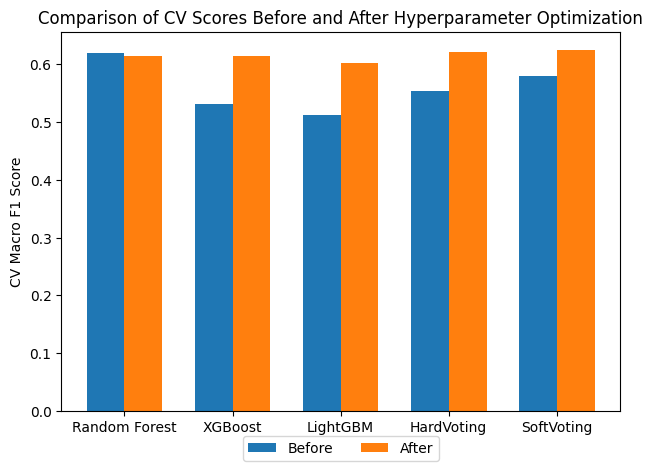

In [97]:
# Combine the dataframes for visualization
comparison_df = pd.merge(comparison_df_before, comparison_df_after, on='Model', suffixes=('_before', '_after'))

# Set the position of bars on X axis
bar_width = 0.35
x = np.arange(len(comparison_df['Model']))

# Create the bar plots with adjusted colors
plt.bar(x - bar_width/2, comparison_df['CV_Macro_F1_score_before'], width=bar_width, label='Before', color='#1f77b4')  # Blue
plt.bar(x + bar_width/2, comparison_df['CV_Macro_F1_score_after'], width=bar_width, label='After', color='#ff7f0e')   # Orange

# Adding labels and title
plt.ylabel('CV Macro F1 Score')
plt.title('Comparison of CV Scores Before and After Hyperparameter Optimization')
plt.xticks(x, comparison_df['Model'])

# Move the legend to the bottom
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Show the plot
plt.tight_layout()
plt.show()

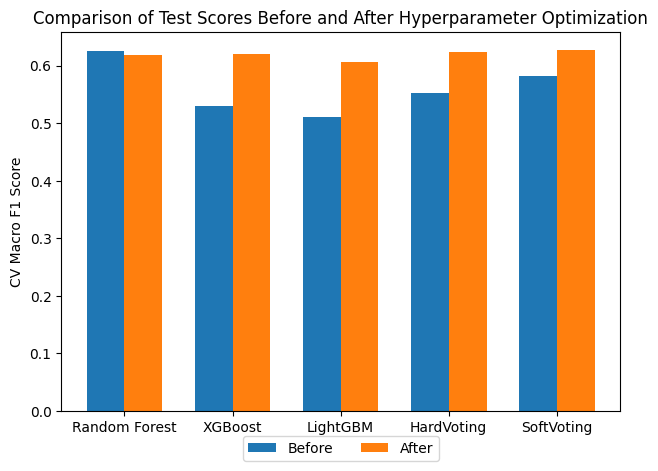

In [98]:
# Combine the dataframes for visualization
comparison_df = pd.merge(comparison_df_before, comparison_df_after, on='Model', suffixes=('_before', '_after'))

# Set the position of bars on X axis
bar_width = 0.35
x = np.arange(len(comparison_df['Model']))

# Create the bar plots with adjusted colors
plt.bar(x - bar_width/2, comparison_df['Test_Macro_F1_score_before'], width=bar_width, label='Before', color='#1f77b4')  # Blue
plt.bar(x + bar_width/2, comparison_df['Test_Macro_F1_score_after'], width=bar_width, label='After', color='#ff7f0e')   # Orange

# Adding labels and title
plt.ylabel('CV Macro F1 Score')
plt.title('Comparison of Test Scores Before and After Hyperparameter Optimization')
plt.xticks(x, comparison_df['Model'])

# Move the legend to the bottom
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Show the plot
plt.tight_layout()
plt.show()

#### Save the model to a file

In [99]:
joblib.dump(rf_classifier_final, 'rf_classifier_final_model.pkl')
joblib.dump(xgb_classifier_final, 'xgb_classifier_final_model.pkl')
joblib.dump(lgb_classifier_final, 'lgb_classifier_final_model.pkl')
joblib.dump(hard_voting_classifier, 'hard_voting_classifier_model.pkl')
joblib.dump(final_soft_voting_classifier, 'final_soft_voting_classifier_model.pkl');

#### Load the model from the file

In [100]:
rf_classifier_final = joblib.load('rf_classifier_final_model.pkl')
xgb_classifier_final = joblib.load('xgb_classifier_final_model.pkl')
lgb_classifier_final = joblib.load('lgb_classifier_final_model.pkl')
hard_voting_classifier = joblib.load('hard_voting_classifier_model.pkl')
final_soft_voting_classifier = joblib.load('final_soft_voting_classifier_model.pkl')

#### Overall Summary

The results indicate that hyperparameter optimization can lead to significant improvements in model performance, particularly for XGBoost and LightGBM, which demonstrated the most substantial gains. Despite these enhancements, Random Forest continues to slightly outperform both XGBoost and LightGBM, maintaining its status as the most effective model overall.

The improvements observed in XGBoost and LightGBM also positively impacted the performance of the ensemble methods, Hard Voting and Soft Voting. Notably, both the cross-validation and test scores for Hard Voting and Soft Voting exceeded those of Random Forest, highlighting the effectiveness of combining models through ensemble techniques when properly tuned.

This analysis underscores the importance of hyperparameter tuning in maximizing the predictive capabilities of machine learning models and suggests that ensemble methods can achieve competitive performance with careful optimization.

#### Iterative Hyperparameter Tuning for Enhanced Model Performance
To enhance model performance, an iterative hyperparameter tuning approach can be employed. This method involves refining the hyperparameter search process in multiple rounds, rather than relying on a single set of hyperparameters. The process begins with selecting an initial set of hyperparameters, evaluating their performance using cross-validation, and then adjusting the search scope based on the results. This iterative cycle continues, with each round narrowing down or expanding the hyperparameter space, until the cross-validation score, such as the macro F1 score, ceases to improve. This approach allows for a more thorough exploration of the hyperparameter landscape, potentially leading to improved model performance. However, it requires careful consideration of computational resources and the risk of overfitting to ensure optimal results.
